In [1]:
%run ../setup.py
%load_ext autoreload
%autoreload 2
# ============= 
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.2f}".format)
# ============= VISUALIZE AND CONFIG PARAMS =======
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({
    'figure.figsize': (12, 8),
    'figure.dpi': 100,
    'font.size': 12,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'legend.fontsize': 12,
    'lines.linewidth': 2,
    'grid.alpha': 0.3,
    'savefig.dpi': 300,
})
# ============= DATA RAW ==========================
from utils.data_loader import load_retail_data
# ============= OVERVIEW ==========================
from src.preprocessing import overview_data
# ============= TURN OFF THE WARNING ==============
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = load_retail_data()
overview_data(df)

Kích thước dữ liệu = (541909,8)

Bảng Kiểu dữ liệu
<class 'pandas.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[us]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 33.1+ MB
None

Bảng Phân phối dữ liệu
        InvoiceNo StockCode                         Description   Quantity  \
count  541,909.00    541909                              540455 541,909.00   
unique  25,900.00      4070                                4223        NaN 

# Khám phá dữ liệu EDA (Rút gọn ý chính)

## 0) Tách dữ liệu làm 2 phần (Hợp lệ và Hoàn trả)

In [29]:
# ===== Tập dữ liệu các đơn hàng bị hủy ======
mask_refund = df['InvoiceNo'].astype(str).str.startswith('C')
df_refund = df[mask_refund].copy()
# ===== Tập dữ liệu các đơn hàng hợp lệ ======
mask_valid = (df['Quantity'] > 0) & \
            (df['UnitPrice'] > 0) & \
            (~df['InvoiceNo'].astype(str).isin(['A','C']))
df_valid = df[mask_valid].copy()
# ============================================
print(f"Kích thước tập dữ liệu hợp lệ {df_valid.shape}")
print(f"Kích thước tập dữ liệu hủy hàng {df_refund.shape}")

print(f"Kích thước tập dữ liệu khuyến mãi ({df[~(mask_refund | mask_valid)].shape})")

Kích thước tập dữ liệu hợp lệ (530104, 8)
Kích thước tập dữ liệu hủy hàng (9288, 8)
Kích thước tập dữ liệu khuyến mãi ((2517, 8))


In [30]:
df[~(mask_refund | mask_valid)].describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,"2,517.00",2517,"2,517.00",40.00
mean,-53.38,2011-06-06 22:29:58.045292,-8.79,"14,217.23"
min,"-9,600.00",2010-12-01 11:52:00,"-11,062.06","12,415.00"
25%,-32.00,2011-03-18 11:02:00,0.00,"12,722.75"
50%,-1.00,2011-05-23 15:31:00,0.00,"13,985.00"
75%,3.00,2011-09-19 16:58:00,0.00,"15,225.50"
max,"12,540.00",2011-12-08 15:24:00,0.00,"18,059.00"
std,539.99,NaN,311.76,"1,676.32"


## 1) Phân phối doanh thu theo thời gian

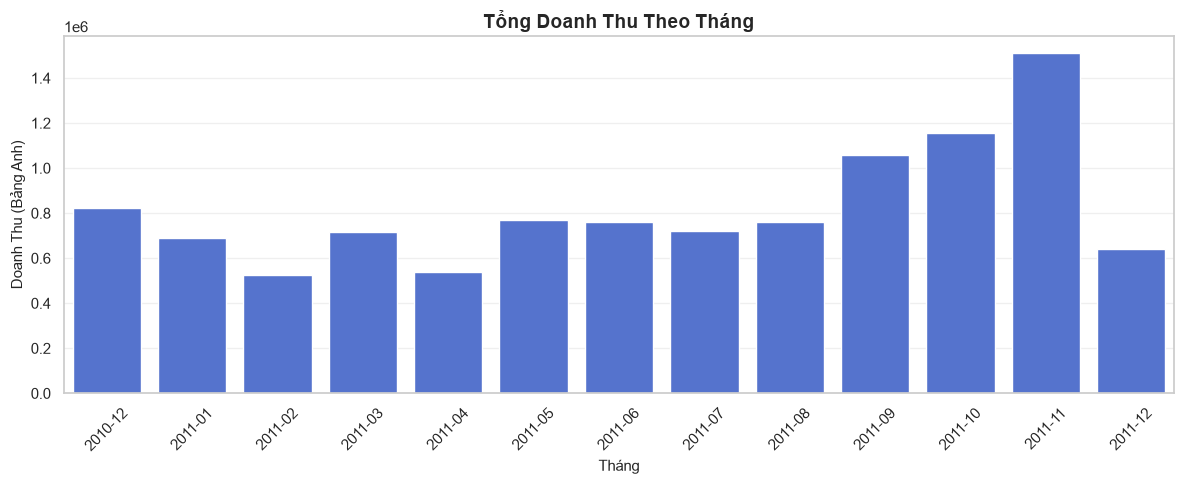

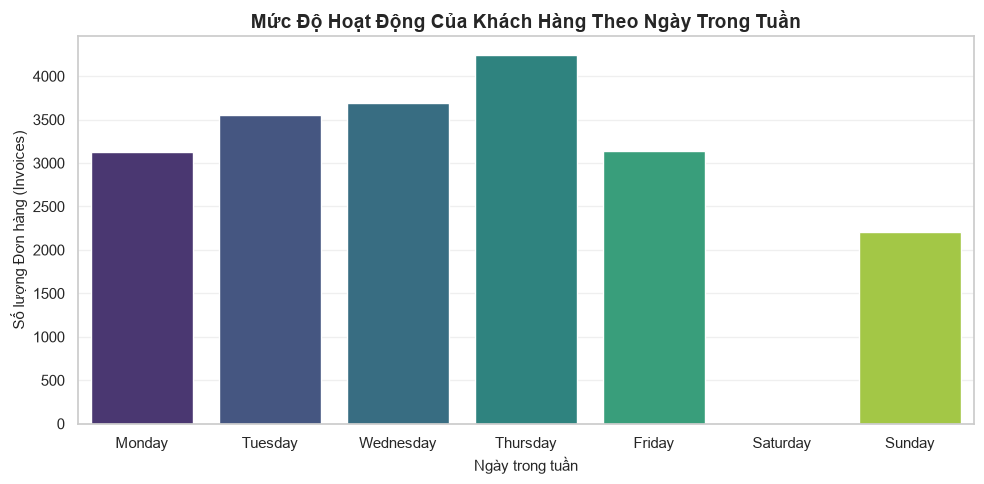

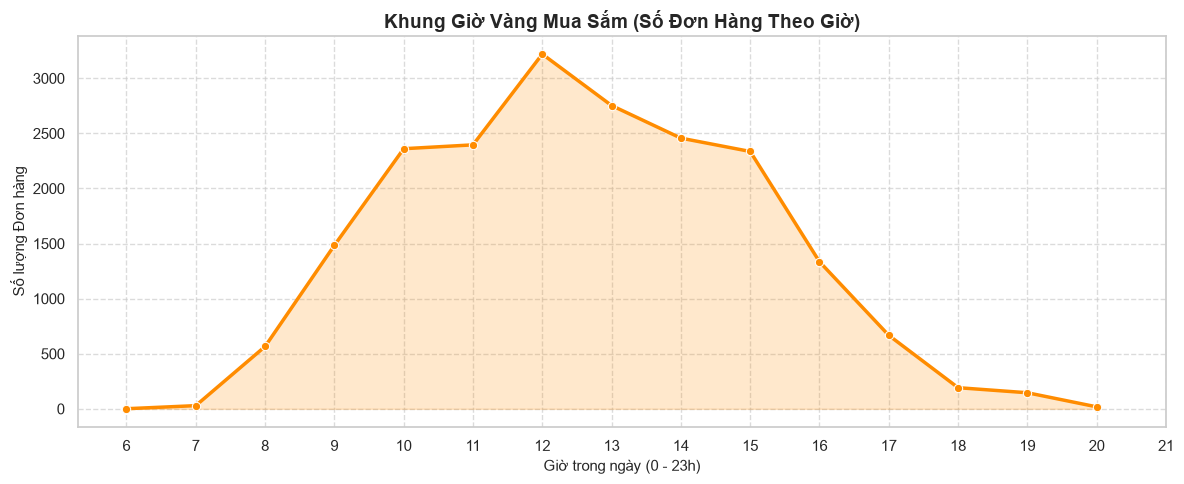

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Để tránh lỗi SettingWithCopyWarning của Pandas khi tạo cột mới
df_valid = df_valid.copy()

# =====================================================================
# 1. TẠO FEATURE TẠM THỜI (ON-THE-FLY FEATURE ENGINEERING)
# =====================================================================
# Chuyển InvoiceDate sang định dạng Datetime (Nếu chưa chuyển)
df_valid['InvoiceDate'] = pd.to_datetime(df_valid['InvoiceDate'])

# Tính Doanh thu (Revenue) = Số lượng * Đơn giá
df_valid['Revenue'] = df_valid['Quantity'] * df_valid['UnitPrice']

# Trích xuất Tháng-Năm, Ngày trong tuần và Giờ
df_valid['YearMonth'] = df_valid['InvoiceDate'].dt.to_period('M').astype(str)
df_valid['DayOfWeek'] = df_valid['InvoiceDate'].dt.day_name()
df_valid['Hour'] = df_valid['InvoiceDate'].dt.hour

days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df_valid['DayOfWeek'] = pd.Categorical(df_valid['DayOfWeek'], categories=days_order, ordered=True)

sns.set_theme(style="whitegrid")

# =====================================================================
# 2. VẼ BIỂU ĐỒ 1: DOANH THU THEO THÁNG (TREND)
# =====================================================================
plt.figure(figsize=(12, 5))
# Gom nhóm tính tổng doanh thu theo tháng
monthly_revenue = df_valid.groupby('YearMonth')['Revenue'].sum().reset_index()

sns.barplot(data=monthly_revenue, x='YearMonth', y='Revenue', color='royalblue')
plt.title('Tổng Doanh Thu Theo Tháng', fontsize=14, fontweight='bold')
plt.xlabel('Tháng', fontsize=11)
plt.ylabel('Doanh Thu (Bảng Anh)', fontsize=11)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# =====================================================================
# 3. VẼ BIỂU ĐỒ 2: SỐ LƯỢNG ĐƠN HÀNG THEO NGÀY TRONG TUẦN
# =====================================================================
plt.figure(figsize=(10, 5))
# Đếm số lượng InvoiceNo (số đơn hàng) theo ngày
daily_orders = df_valid.groupby('DayOfWeek')['InvoiceNo'].nunique().reset_index()

sns.barplot(data=daily_orders, x='DayOfWeek', y='InvoiceNo', palette='viridis')
plt.title('Mức Độ Hoạt Động Của Khách Hàng Theo Ngày Trong Tuần', fontsize=14, fontweight='bold')
plt.xlabel('Ngày trong tuần', fontsize=11)
plt.ylabel('Số lượng Đơn hàng (Invoices)', fontsize=11)
plt.tight_layout()
plt.show()

# =====================================================================
# 4. VẼ BIỂU ĐỒ 3: KHUNG GIỜ VÀNG MUA SẮM
# =====================================================================
plt.figure(figsize=(12, 5))
# Đếm số đơn hàng theo giờ
hourly_orders = df_valid.groupby('Hour')['InvoiceNo'].nunique().reset_index()

sns.lineplot(data=hourly_orders, x='Hour', y='InvoiceNo', marker='o', linewidth=2.5, color='darkorange')
plt.fill_between(hourly_orders['Hour'], hourly_orders['InvoiceNo'], color='darkorange', alpha=0.2)

plt.title('Khung Giờ Vàng Mua Sắm (Số Đơn Hàng Theo Giờ)', fontsize=14, fontweight='bold')
plt.xlabel('Giờ trong ngày (0 - 23h)', fontsize=11)
plt.ylabel('Số lượng Đơn hàng', fontsize=11)
plt.xticks(range(6, 22))
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 2) Thống kê sản phẩm và Hành vi hoàn trả

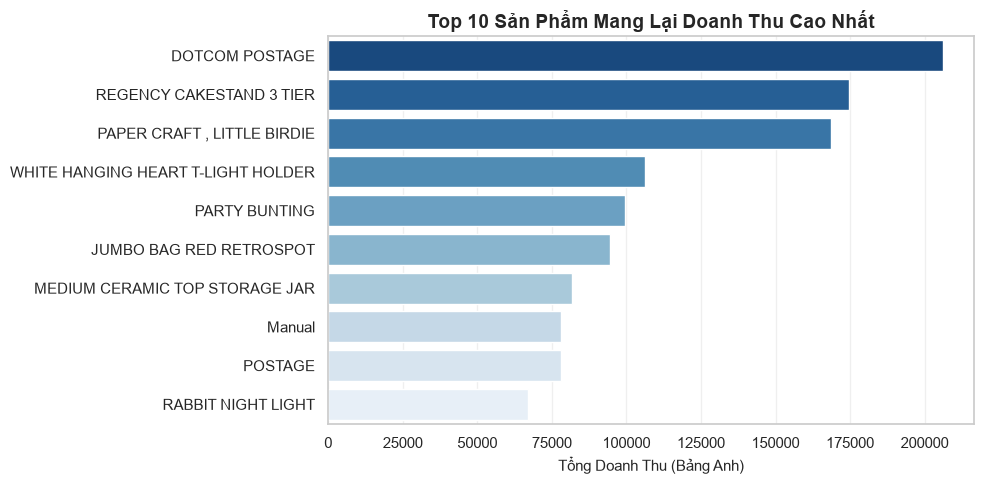

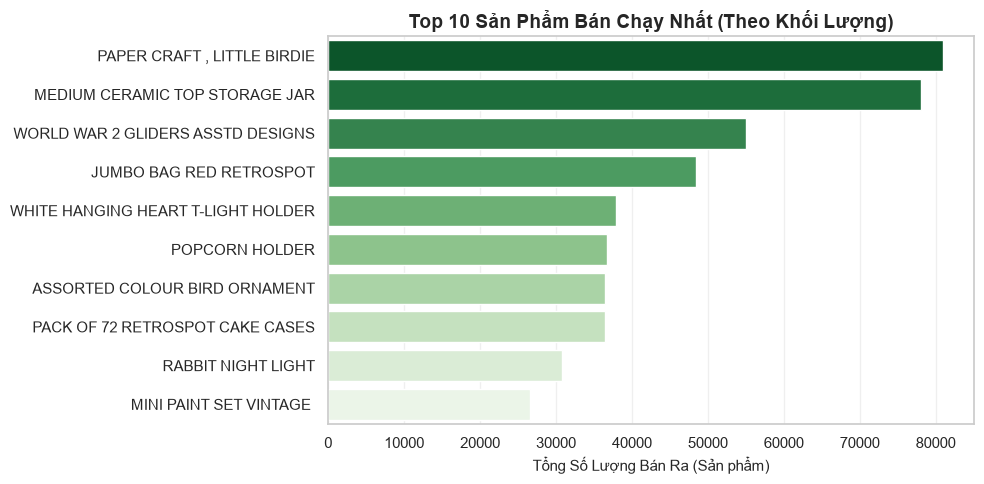

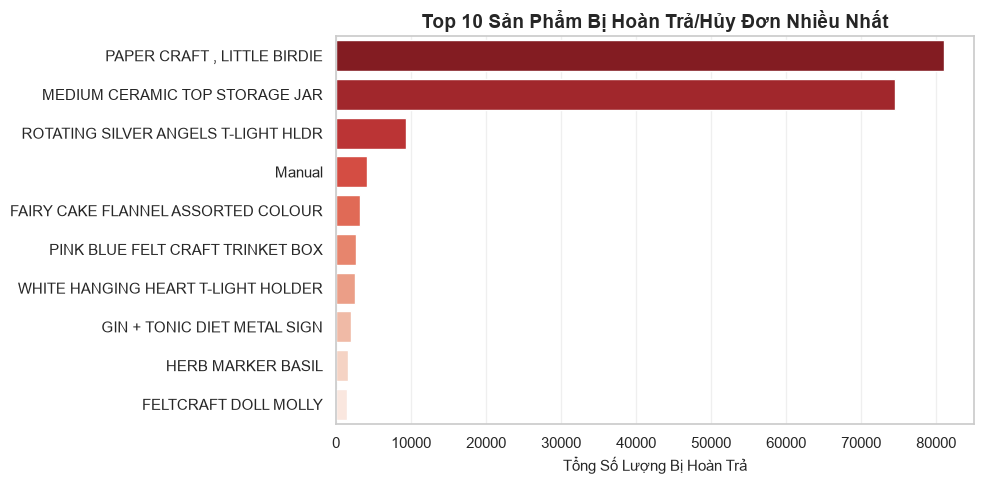

In [34]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================================
# CHUẨN BỊ DỮ LIỆU
# =====================================================================
df_valid_prod = df_valid.dropna(subset=['Description']).copy()
df_refund_prod = df_refund.dropna(subset=['Description']).copy()

# 1. Top 10 Doanh thu
top10_revenue = df_valid_prod.groupby('Description')['Revenue'].sum().reset_index()
top10_revenue = top10_revenue.sort_values(by='Revenue', ascending=False).head(10)

# 2. Top 10 Số lượng
top10_quantity = df_valid_prod.groupby('Description')['Quantity'].sum().reset_index()
top10_quantity = top10_quantity.sort_values(by='Quantity', ascending=False).head(10)

# 3. Top 10 Hoàn trả
df_refund_prod['Returned_Qty'] = df_refund_prod['Quantity'].abs()
top10_returned = df_refund_prod.groupby('Description')['Returned_Qty'].sum().reset_index()
top10_returned = top10_returned.sort_values(by='Returned_Qty', ascending=False).head(10)

sns.set_theme(style="whitegrid")

# =====================================================================
# HÌNH 1: TOP DOANH THU
# =====================================================================
plt.figure(figsize=(10, 5))
sns.barplot(data=top10_revenue, x='Revenue', y='Description', palette='Blues_r')
plt.title('Top 10 Sản Phẩm Mang Lại Doanh Thu Cao Nhất', fontsize=14, fontweight='bold')
plt.xlabel('Tổng Doanh Thu (Bảng Anh)', fontsize=11)
plt.ylabel('')
plt.tight_layout()
plt.show()

# =====================================================================
# HÌNH 2: TOP SỐ LƯỢNG (BÁN CHẠY NHẤT)
# =====================================================================
plt.figure(figsize=(10, 5))
sns.barplot(data=top10_quantity, x='Quantity', y='Description', palette='Greens_r')
plt.title('Top 10 Sản Phẩm Bán Chạy Nhất (Theo Khối Lượng)', fontsize=14, fontweight='bold')
plt.xlabel('Tổng Số Lượng Bán Ra (Sản phẩm)', fontsize=11)
plt.ylabel('')
plt.tight_layout()
plt.show()

# =====================================================================
# HÌNH 3: TOP HOÀN TRẢ / HỦY ĐƠN
# =====================================================================
plt.figure(figsize=(10, 5))
sns.barplot(data=top10_returned, x='Returned_Qty', y='Description', palette='Reds_r')
plt.title('Top 10 Sản Phẩm Bị Hoàn Trả/Hủy Đơn Nhiều Nhất', fontsize=14, fontweight='bold')
plt.xlabel('Tổng Số Lượng Bị Hoàn Trả', fontsize=11)
plt.ylabel('')
plt.tight_layout()
plt.show()

## 3) Phân tích khách hàng và vị trí địa lý

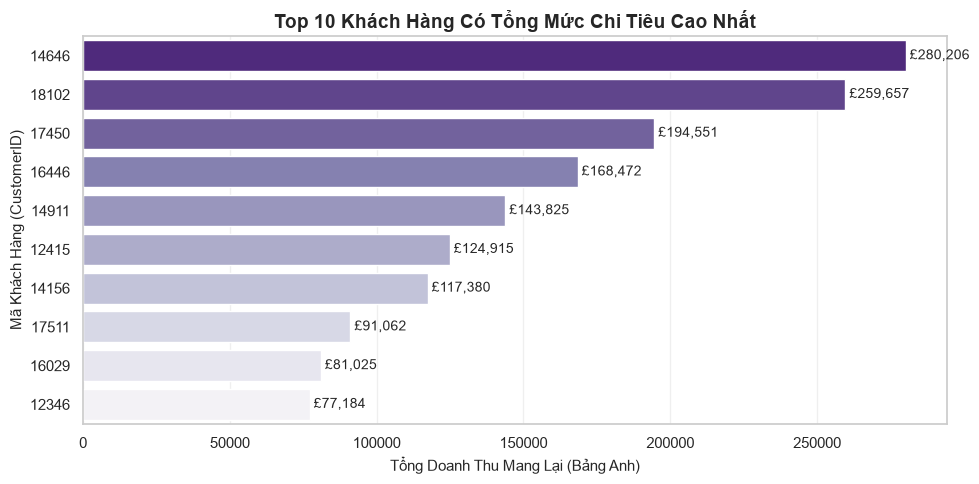

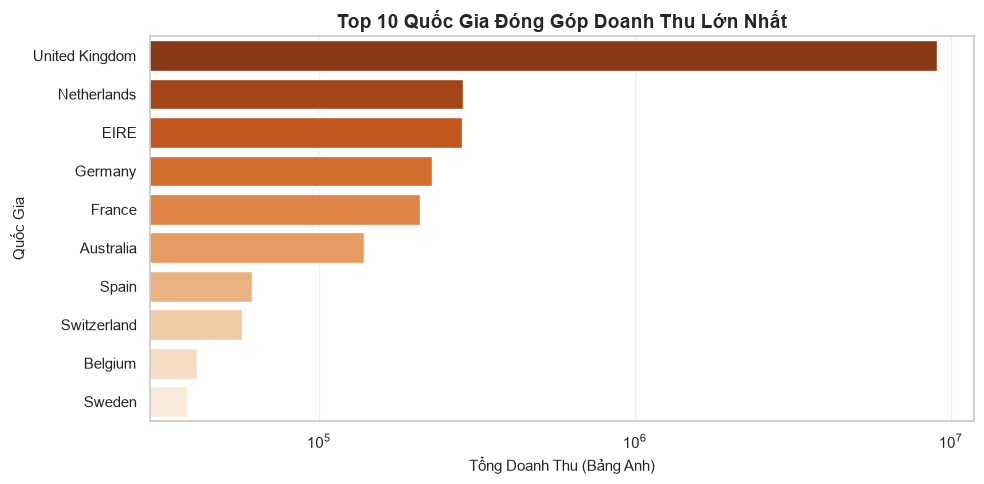

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =====================================================================
# CHUẨN BỊ DỮ LIỆU
# =====================================================================

df_valid_cust = df_valid.dropna(subset=['CustomerID']).copy()
df_valid_cust['CustomerID'] = df_valid_cust['CustomerID'].astype(int).astype(str)

# 1. Top 10 Khách hàng chi mạnh tay nhất (VIP)
top10_customers = df_valid_cust.groupby('CustomerID')['Revenue'].sum().reset_index()
top10_customers = top10_customers.sort_values(by='Revenue', ascending=False).head(10)

# 2. Top 10 Quốc gia mang lại doanh thu cao nhất
top10_countries = df_valid.groupby('Country')['Revenue'].sum().reset_index()
top10_countries = top10_countries.sort_values(by='Revenue', ascending=False).head(10)

sns.set_theme(style="whitegrid")

# =====================================================================
# HÌNH 1: TOP 10 KHÁCH HÀNG (VIP)
# =====================================================================
plt.figure(figsize=(10, 5))

sns.barplot(data=top10_customers, x='Revenue', y='CustomerID', order=top10_customers['CustomerID'], palette='Purples_r')
plt.title('Top 10 Khách Hàng Có Tổng Mức Chi Tiêu Cao Nhất', fontsize=14, fontweight='bold')
plt.xlabel('Tổng Doanh Thu Mang Lại (Bảng Anh)', fontsize=11)
plt.ylabel('Mã Khách Hàng (CustomerID)', fontsize=11)

for index, value in enumerate(top10_customers['Revenue']):
    plt.text(value, index, f' £{value:,.0f}', va='center', fontsize=10)

plt.tight_layout()
plt.show()

# =====================================================================
# HÌNH 2: TOP 10 QUỐC GIA (THỊ TRƯỜNG ĐỊA LÝ)
# =====================================================================
plt.figure(figsize=(10, 5))

sns.barplot(data=top10_countries, x='Revenue', y='Country', palette='Oranges_r')
plt.title('Top 10 Quốc Gia Đóng Góp Doanh Thu Lớn Nhất', fontsize=14, fontweight='bold')
plt.xlabel('Tổng Doanh Thu (Bảng Anh)', fontsize=11)
plt.ylabel('Quốc Gia', fontsize=11)

plt.xscale('log')

plt.tight_layout()
plt.show()